<a href="https://colab.research.google.com/github/manju2187/fighter-jet-analysis/blob/main/Testty1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



In [ ]:
df = pd.read_csv('/fighter_aircraft_dataset_v10.csv')

# Fix bool columns
colcov = ['Supercruise_Capable', 'Thrust_Vectoring', 'Internal_Weapons_Bay']
df[colcov] = df[colcov].replace({'Yes': True, 'No': False}).astype(bool)

# Create target variable
df['Is_5th_Gen'] = (df['Generation'] == '5').astype(int)

print(df['Is_5th_Gen'].value_counts())

Is_5th_Gen
0    43
1     5
Name: count, dtype: int64


/tmp/ipykernel_3139/3127860577.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colcov] = df[colcov].replace({'Yes': True, 'No': False}).astype(bool)


In [ ]:
features = ['Max_Speed_kmh', 'RCS_m2', 'Unit_Cost_M_USD',
            'Empty_Weight_kg', 'MTOW_kg', 'Combat_Radius_km',
            'Max_Weapon_Load_kg', 'Thrust_per_Engine_kN']

X = df[features].fillna(df[features].mean())
y = df['Is_5th_Gen']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 38
Testing samples: 10


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

                feature  importance
1                RCS_m2    0.430312
7  Thrust_per_Engine_kN    0.139108
4               MTOW_kg    0.127034
2       Unit_Cost_M_USD    0.111141
3       Empty_Weight_kg    0.073106
0         Max_Speed_kmh    0.048708
5      Combat_Radius_km    0.039636
6    Max_Weapon_Load_kg    0.030955


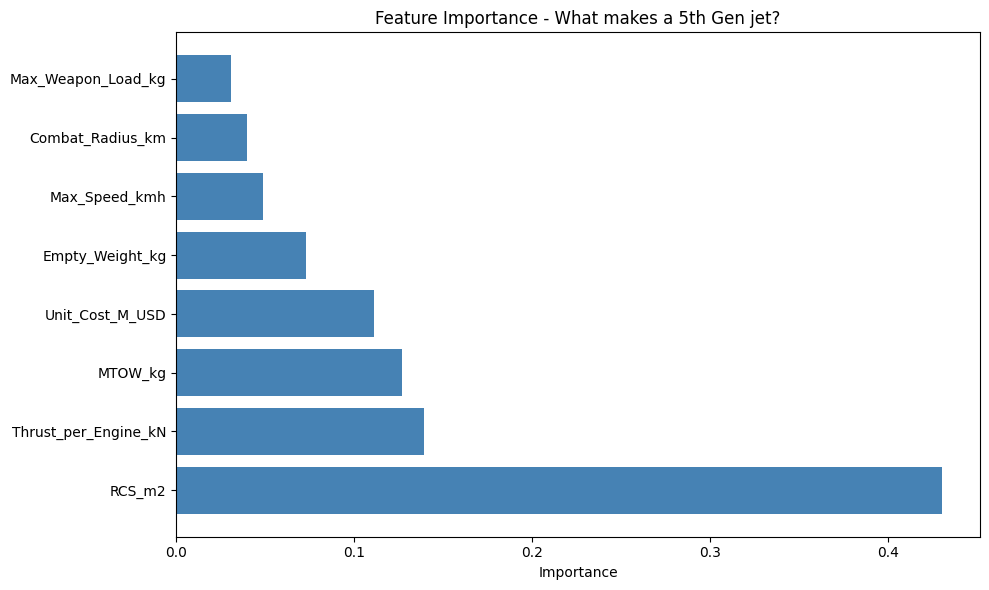

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - What makes a 5th Gen jet?')
plt.tight_layout()
plt.savefig('feature_importance.png')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

features = ['RCS_m2', 'Thrust_per_Engine_kN', 'MTOW_kg',
            'Max_Speed_kmh', 'Empty_Weight_kg', 'Combat_Radius_km']

X = df[features].fillna(df[features].mean())
y = df['Unit_Cost_M_USD'].fillna(df['Unit_Cost_M_USD'].mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")

R2 Score: 0.5674954580206585
Mean Absolute Error: 19.714443710601437


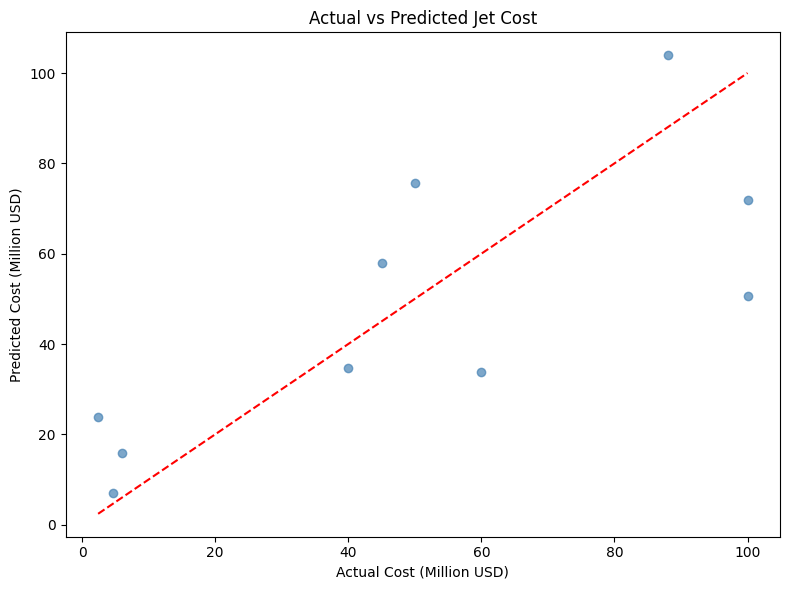

In [ ]:

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Cost (Million USD)')
plt.ylabel('Predicted Cost (Million USD)')
plt.title('Actual vs Predicted Jet Cost')
plt.tight_layout()
plt.savefig('regression_results.png')

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

features = ['Max_Speed_kmh', 'RCS_m2', 'Unit_Cost_M_USD',
            'Empty_Weight_kg', 'MTOW_kg', 'Combat_Radius_km',
            'Max_Weapon_Load_kg', 'Thrust_per_Engine_kN']

X = df[features].fillna(df[features].mean())
y = df['Is_5th_Gen']

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"Individual fold scores: {scores}")
print(f"Mean accuracy: {scores.mean()}")
print(f"Standard deviation: {scores.std()}")

Individual fold scores: [1.         1.         0.9        1.         0.88888889]
Mean accuracy: 0.9577777777777777
Standard deviation: 0.05183068350973601
